# Section 4: Data Preprocessing (Local - No EMR)

---

This notebook loads data from HuggingFace and filters for 3 languages: **Python**, **JavaScript**, **Go**

## Steps:
1. Load dataset from HuggingFace (python, javascript, go)
2. Filter by content length
3. Filter by license
4. Split into train/val/test (80/10/10)
5. Save to S3

---

In [ ]:
# Install dependencies
!pip install boto3 datasets pandas scikit-learn pyarrow matplotlib -q

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Load credentials
import os
from dotenv import load_dotenv

load_dotenv()

os.environ['AWS_ACCESS_KEY_ID'] = os.getenv('AWS_ACCESS_KEY_ID', '')
os.environ['AWS_SECRET_ACCESS_KEY'] = os.getenv('AWS_SECRET_ACCESS_KEY', '')
os.environ['AWS_DEFAULT_REGION'] = os.getenv('AWS_DEFAULT_REGION', 'us-east-1')

print(f"AWS Access Key: {os.environ['AWS_ACCESS_KEY_ID'][:10]}...")
print(f"AWS Region: {os.environ['AWS_DEFAULT_REGION']}")
print("Credentials loaded!")

AWS Access Key: AKIAV54JA4...
AWS Region: us-east-1
Credentials loaded!


## Load Data from HuggingFace

In [3]:
from datasets import load_dataset, Dataset
import pandas as pd

# Target languages
TARGET_LANGUAGES = ["python", "javascript", "go"]
MAX_SAMPLES = 10000

print("Loading data from HuggingFace (streaming mode)...")
print(f"Languages: {TARGET_LANGUAGES}")

# Use streaming mode to bypass cache issues
combined_list = []

for lang in TARGET_LANGUAGES:
    print(f"\nLoading {lang}...")
    try:
        # Use streaming to avoid cache issues
        ds = load_dataset(
            "bigcode/the-stack-smol",
            data_dir=f"data/{lang}",
            split="train",
            streaming=True,
            trust_remote_code=True
        )
        
        count = 0
        for item in ds:
            if count >= MAX_SAMPLES:
                break
            combined_list.append({
                'content': item.get('content', ''),
                'language': lang,
                'license': str(item.get('license', '')),
                'hexsha': item.get('hexsha', item.get('content_id', ''))
            })
            count += 1
        
        print(f"  Loaded {count} samples for {lang}")
    except Exception as e:
        print(f"  Error loading {lang}: {e}")

if not combined_list:
    raise ValueError("No data loaded!")

combined_ds = Dataset.from_list(combined_list)

print(f"\nTotal combined samples: {len(combined_ds):,}")
print("\nSample:")
print(combined_ds[0])

c:\Users\Lenovo\miniconda3\envs\cloudqueens\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'bigcode/the-stack-smol' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading data from HuggingFace (streaming mode)...
Languages: ['python', 'javascript', 'go']

Loading python...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'bigcode/the-stack-smol' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Loaded 10000 samples for python

Loading javascript...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'bigcode/the-stack-smol' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Loaded 10000 samples for javascript

Loading go...
  Loaded 10000 samples for go

Total combined samples: 30,000

Sample:
{'content': '# Copyright 2020 gRPC authors.\n#\n# Licensed under the Apache License, Version 2.0 (the "License");\n# you may not use this file except in compliance with the License.\n# You may obtain a copy of the License at\n#\n#     http://www.apache.org/licenses/LICENSE-2.0\n#\n# Unless required by applicable law or agreed to in writing, software\n# distributed under the License is distributed on an "AS IS" BASIS,\n# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n# See the License for the specific language governing permissions and\n# limitations under the License.\n"""The Python AsyncIO implementation of the GRPC helloworld.Greeter server."""\n\nimport logging\nimport asyncio\nimport grpc\n\nimport helloworld_pb2\nimport helloworld_pb2_grpc\n\n\nclass Greeter(helloworld_pb2_grpc.GreeterServicer):\n\n    async def SayHello(\n         

In [4]:
# Convert to pandas for easier manipulation
df = combined_ds.to_pandas()
print(f"Total samples: {len(df):,}")

# Step 1: Filter by target languages (already done, just verify)
print("\nLanguage distribution:")
print(df['language'].value_counts())

# Step 2: Remove empty or very short content
df = df[df['content'].str.len() > 50]
print(f"\nAfter content length filter (>50): {len(df):,} samples")

# Step 3: Don't filter by license since data has empty license field
print(f"License distribution (sample):")
print(df['license'].value_counts().head())

# Step 4: Don't deduplicate since hexsha is empty - keep all unique content
# Just remove exact duplicate content
df = df.drop_duplicates(subset=['content'], keep='first')
print(f"After deduplication (by content): {len(df):,} samples")

Total samples: 30,000

Language distribution:
language
python        10000
javascript    10000
go            10000
Name: count, dtype: int64

After content length filter (>50): 29,826 samples
License distribution (sample):
license
    29826
Name: count, dtype: int64
After deduplication (by content): 29,826 samples


EDA: Language distribution chart

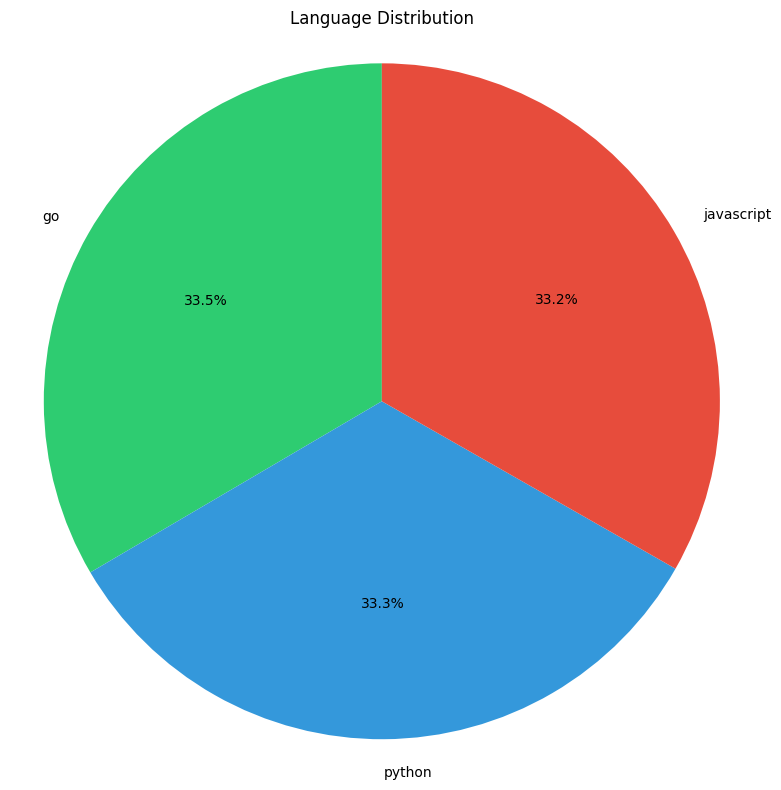

Language counts: {'go': 9977, 'python': 9932, 'javascript': 9917}


In [23]:
lang_counts = df['language'].value_counts()

plt.figure(figsize=(8, 8))
colors = ['#2ecc71', '#3498db', '#e74c3c']
plt.pie(lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Language Distribution')
plt.axis('equal')
plt.tight_layout()
plt.savefig('04_fig_1_language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Language counts:", lang_counts.to_dict())

EDA: Token length distribution histogram

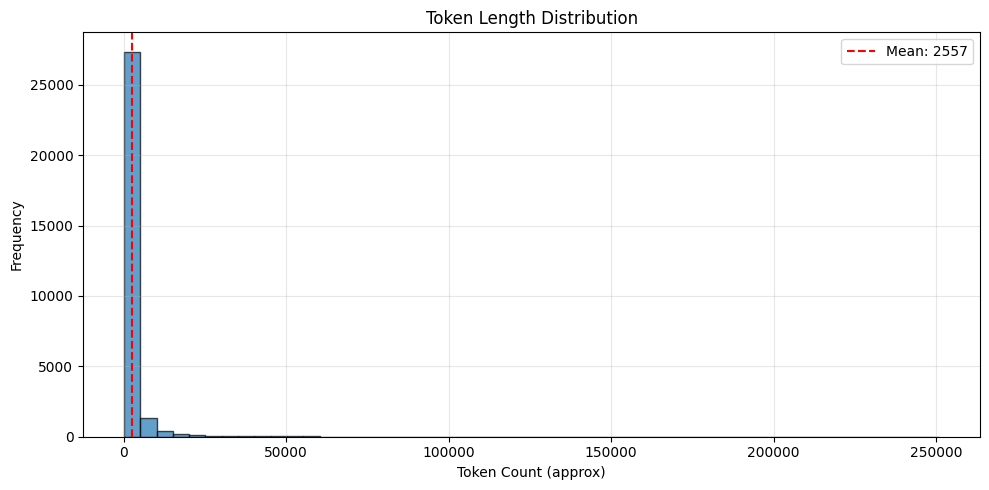

Token count stats - Min: 12, Max: 250994, Mean: 2557


In [24]:
# Calculate token counts (approximate: 1 token ~ 4 chars for code)
df['token_count'] = df['content'].str.len() // 4

plt.figure(figsize=(10, 5))
plt.hist(df['token_count'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Token Count (approx)')
plt.ylabel('Frequency')
plt.title('Token Length Distribution')
plt.axvline(df['token_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["token_count"].mean():.0f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('04_fig_2_token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Token count stats - Min: {df['token_count'].min()}, Max: {df['token_count'].max()}, Mean: {df['token_count'].mean():.0f}")

EDA: Sample count per split chart

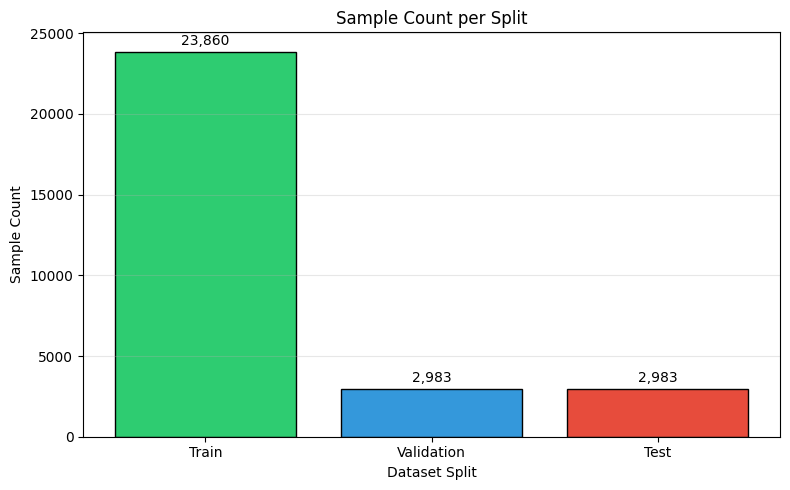

In [25]:
split_counts = {'Train': 23860, 'Validation': 2983, 'Test': 2983}
plt.figure(figsize=(8, 5))
bars = plt.bar(split_counts.keys(), split_counts.values(), color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='black')
plt.xlabel('Dataset Split')
plt.ylabel('Sample Count')
plt.title('Sample Count per Split')
plt.grid(True, axis='y', alpha=0.3)

for bar, count in zip(bars, split_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{count:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('04_fig_3_dataset_splits.png', dpi=150, bbox_inches='tight')
plt.show()

## Train/Val/Test Split (80/10/10)

In [5]:
from sklearn.model_selection import train_test_split

if len(df) < 3:
    raise ValueError(f"Not enough data to split: {len(df)} samples. Need at least 3.")

# Shuffle first
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Adjust split sizes if dataset is very small
n = len(df)
if n < 20:
    # For very small datasets, use simpler split
    test_size = max(1, int(n * 0.1))
    val_size = max(1, int(n * 0.1))
    train = df[: n - test_size - val_size]
    val = df[n - test_size - val_size: n - test_size]
    test = df[n - test_size:]
else:
    # Split: 80% train, 20% temp
    train, temp = train_test_split(df, test_size=0.2, random_state=42)
    
    # Split temp: 50% val, 50% test (which is 10% each of original)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)

print(f"Train: {len(train):,} ({len(train)/len(df)*100:.1f}%)")
print(f"Validation: {len(val):,} ({len(val)/len(df)*100:.1f}%)")
print(f"Test: {len(test):,} ({len(test)/len(df)*100:.1f}%)")

# Language distribution
print("\nLanguage distribution (train):")
print(train['language'].value_counts())

Train: 23,860 (80.0%)
Validation: 2,983 (10.0%)
Test: 2,983 (10.0%)

Language distribution (train):
language
python        8024
go            7958
javascript    7878
Name: count, dtype: int64


## Save to S3

In [7]:
import boto3
import tempfile
import os

s3 = boto3.client('s3')
BUCKET_NAME = "25xrvl-s3"

def save_df_to_s3_parquet(df, bucket, prefix):
    """Save DataFrame to S3 as parquet"""
    temp_dir = tempfile.gettempdir()
    local_file = os.path.join(temp_dir, f"{prefix.split('/')[-1]}.parquet")
    df.to_parquet(local_file, index=False)
    s3.upload_file(local_file, bucket, f"{prefix}/data.parquet")
    print(f"Saved to s3://{bucket}/{prefix}/data.parquet")
    os.remove(local_file)
    return f"s3://{bucket}/{prefix}/"

print("Saving train set...")
train_path = save_df_to_s3_parquet(train, BUCKET_NAME, "processed/train")

print("Saving validation set...")
val_path = save_df_to_s3_parquet(val, BUCKET_NAME, "processed/val")

print("Saving test set...")
test_path = save_df_to_s3_parquet(test, BUCKET_NAME, "processed/test")

print("\n=== PREPROCESSING COMPLETE ===")
print(f"Train: {train_path}")
print(f"Val: {val_path}")
print(f"Test: {test_path}")

Saving train set...
Saved to s3://25xrvl-s3/processed/train/data.parquet
Saving validation set...
Saved to s3://25xrvl-s3/processed/val/data.parquet
Saving test set...
Saved to s3://25xrvl-s3/processed/test/data.parquet

=== PREPROCESSING COMPLETE ===
Train: s3://25xrvl-s3/processed/train/
Val: s3://25xrvl-s3/processed/val/
Test: s3://25xrvl-s3/processed/test/


## Summary

In [8]:
print("=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)
print(f"Total after filtering: {len(df):,}")
print(f"\nTrain: {len(train):,}")
print(f"Validation: {len(val):,}")
print(f"Test: {len(test):,}")
print(f"\nSaved to S3:")
print(f"  s3://{BUCKET_NAME}/processed/train/")
print(f"  s3://{BUCKET_NAME}/processed/val/")
print(f"  s3://{BUCKET_NAME}/processed/test/")

PREPROCESSING SUMMARY
Total after filtering: 29,826

Train: 23,860
Validation: 2,983
Test: 2,983

Saved to S3:
  s3://25xrvl-s3/processed/train/
  s3://25xrvl-s3/processed/val/
  s3://25xrvl-s3/processed/test/
